In [1]:
import yfinance as yf
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fracdiff import fracdiff, fracint


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Calculating fractional differentiation with d=0.01 and threshold=0.0001
Calculating fractional differentiation with d=0.01 and threshold=0.0001
Calculating fractional differentiation with d=0.02 and threshold=0.0001
Calculating fractional differentiation with d=0.02 and threshold=0.0001
Calculating fractional differentiation with d=0.03 and threshold=0.0001
Calculating fractional differentiation with d=0.03 and threshold=0.0001
Calculating fractional differentiation with d=0.04 and threshold=0.0001
Calculating fractional differentiation with d=0.04 and threshold=0.0001
Calculating fractional differentiation with d=0.05 and threshold=0.0001
Calculating fractional differentiation with d=0.05 and threshold=0.0001
Calculating fractional differentiation with d=0.060000000000000005 and threshold=0.0001
Calculating fractional differentiation with d=0.060000000000000005 and threshold=0.0001
Calculating fractional differentiation with d=0.06999999999999999 and threshold=0.0001
Calculating fract

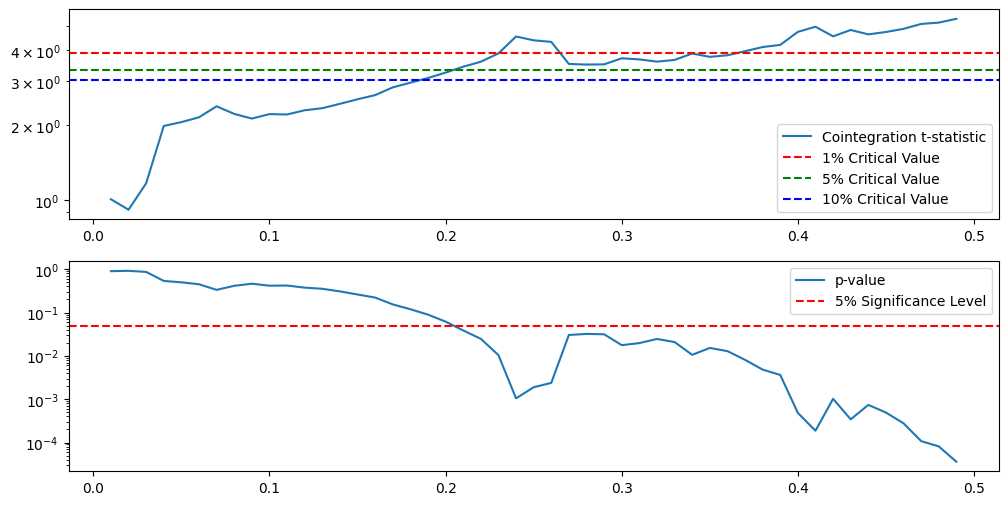

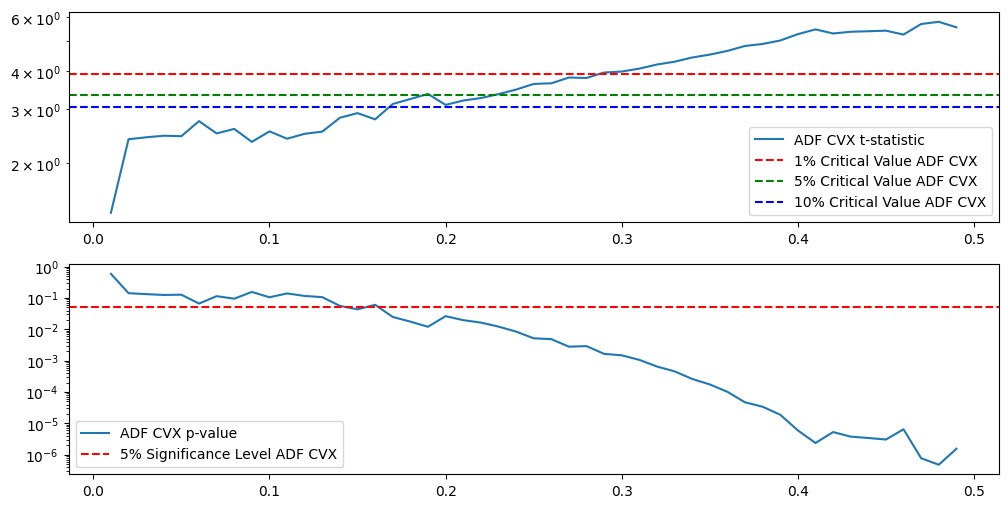

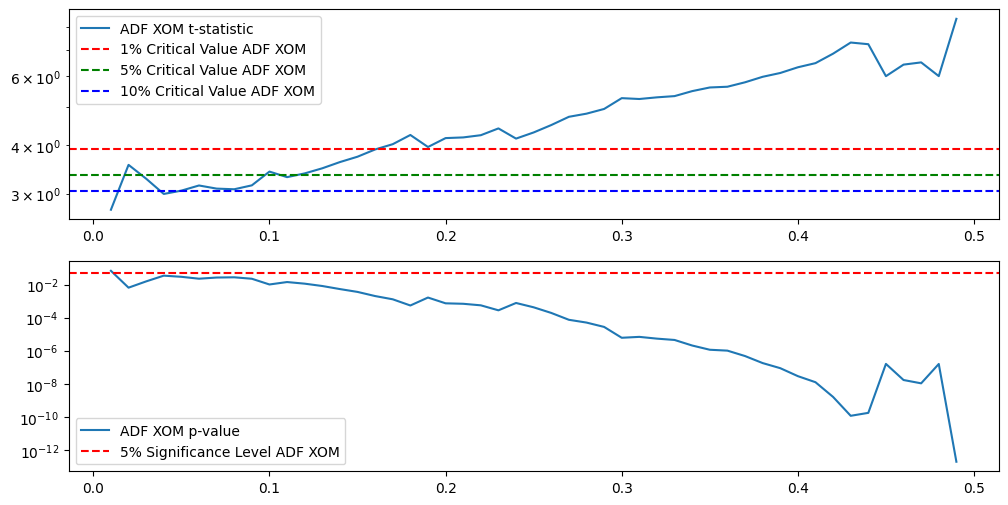

Calculating fractional differentiation with d=0.3 and threshold=0.0001
Calculating fractional differentiation with d=0.3 and threshold=0.0001
For d=0.3, Cointegration t-statistic: -3.7122280650032367, p-value: 0.017672545917717733


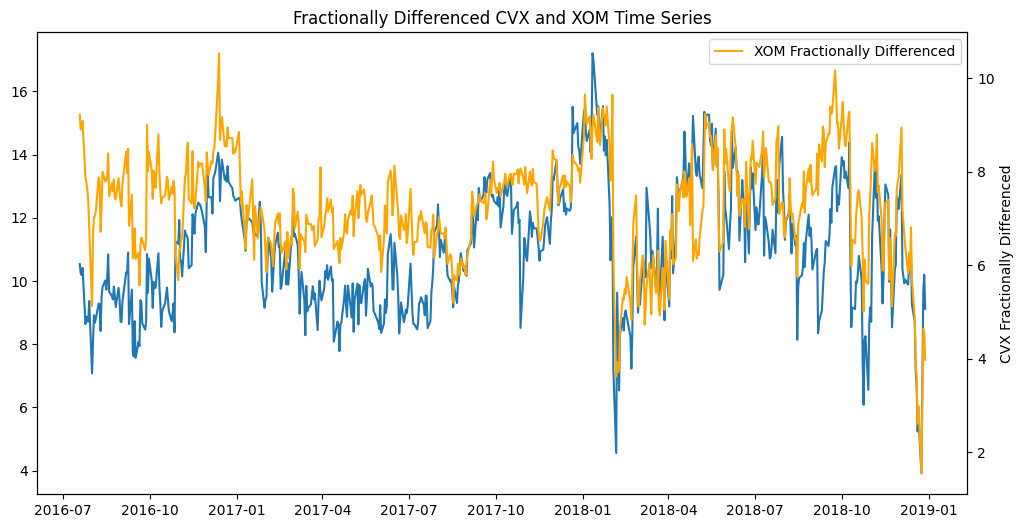

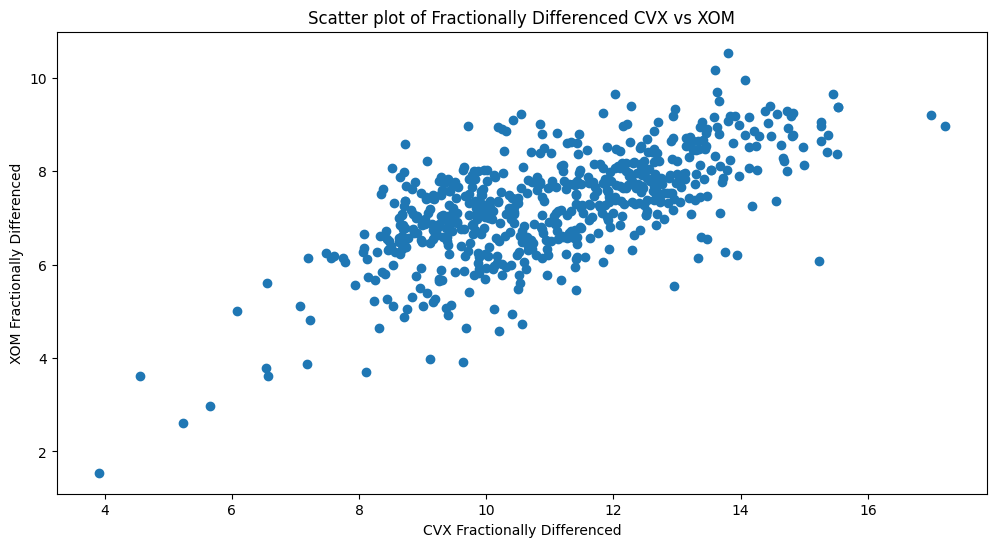

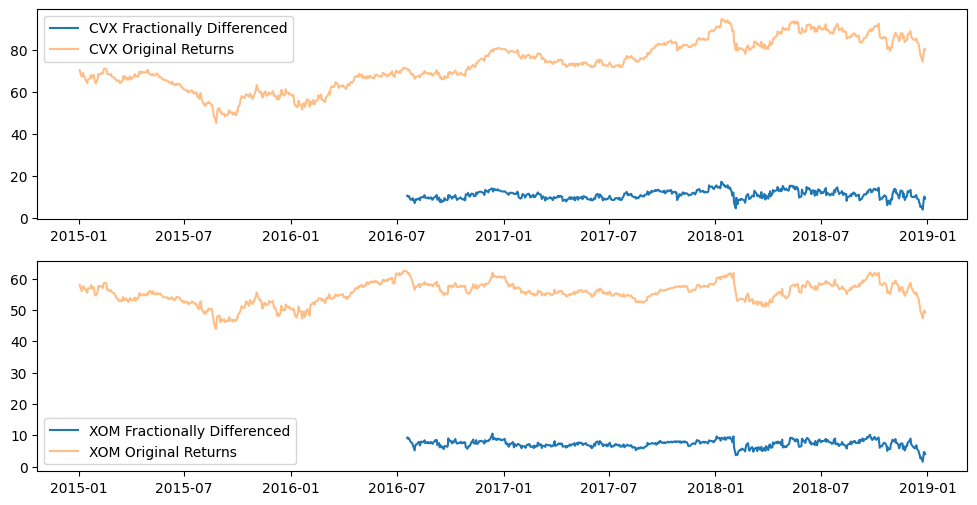

Length CVX original: 1005, Length CVX fd: 617


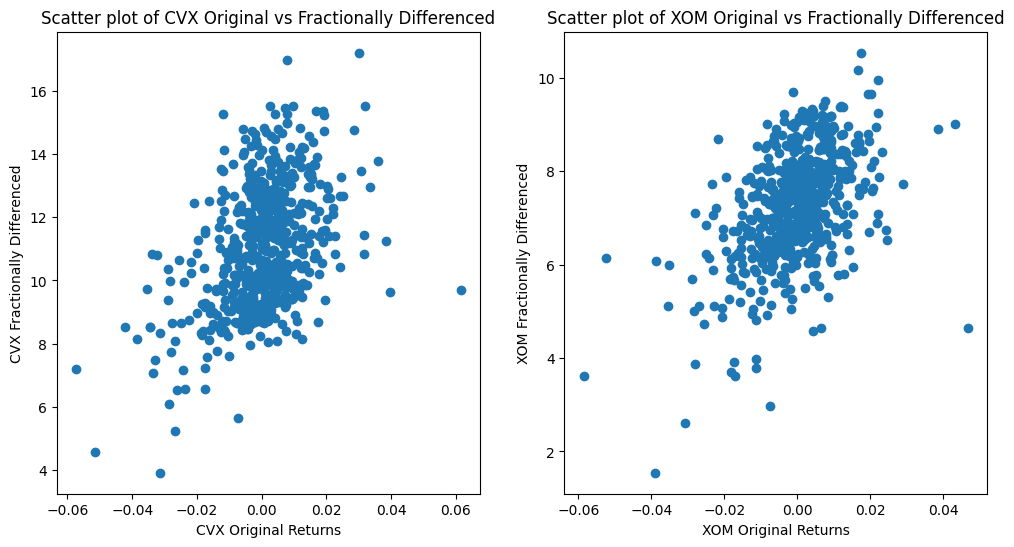

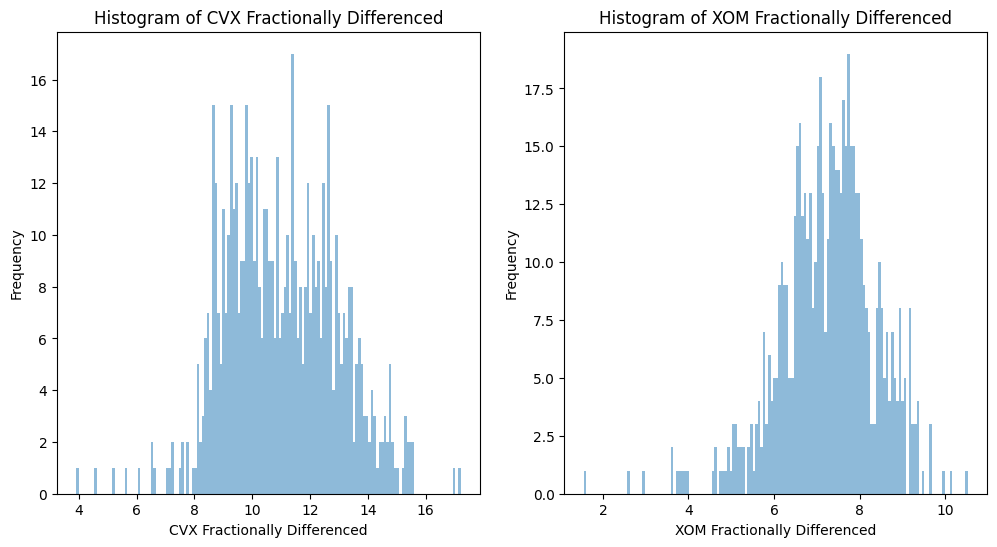

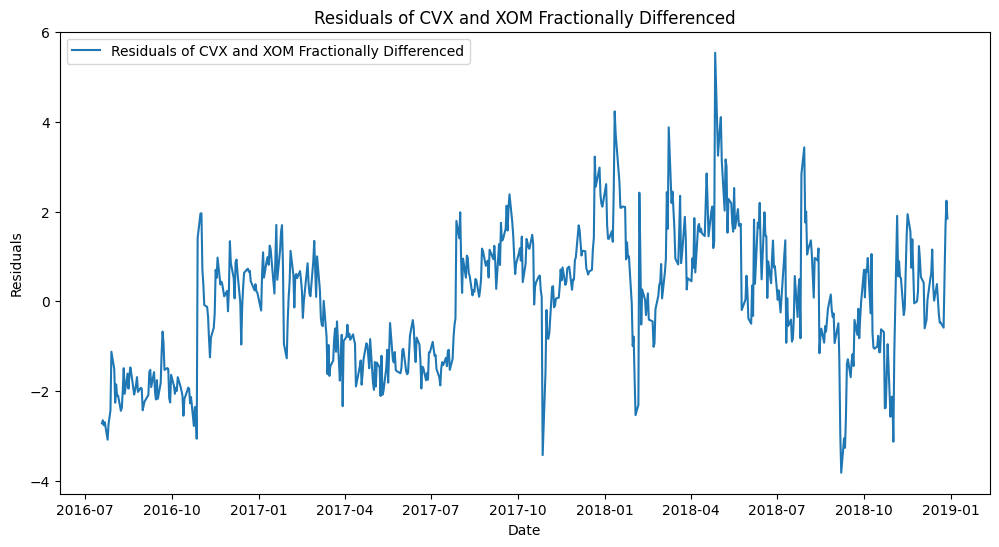

In [2]:
CVX = yf.download('CVX', '2015-01-01', '2018-12-31')['Close'].squeeze()
XOM = yf.download('XOM', '2015-01-01', '2018-12-31')['Close'].squeeze()



d = np.arange(0.01, .5, 0.01)
coint_t = np.zeros(len(d))
p_value = np.zeros(len(d))

coint_t_A = np.zeros(len(d))
p_value_A = np.zeros(len(d))
coint_t_B = np.zeros(len(d))
p_value_B = np.zeros(len(d))

for i in range(len(d)):
    CVX_fd = fracdiff(CVX, d[i], threshold=1e-4)
    XOM_fd = fracdiff(XOM, d[i], threshold=1e-4)
    coint_t[i], p_value[i], critial_values = coint(CVX_fd.dropna(), XOM_fd.dropna())
    coint_t_A[i], p_value_A[i], _, _, _, _ = adfuller(CVX_fd.dropna())
    coint_t_B[i], p_value_B[i], _, _, _, _ = adfuller(XOM_fd.dropna())



plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(d, -coint_t, label='Cointegration t-statistic')
plt.axhline(y=-critial_values[0], color='r', linestyle='--', label='1% Critical Value')
plt.axhline(y=-critial_values[1], color='g', linestyle='--', label='5% Critical Value')
plt.axhline(y=-critial_values[2], color='b', linestyle='--', label='10% Critical Value')
plt.legend()
plt.yscale('log')

plt.subplot(2, 1, 2)
plt.plot(d, p_value, label='p-value')
plt.axhline(y=0.05, color='r', linestyle='--', label='5% Significance Level')
plt.legend()
plt.yscale('log')
plt.show()


plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(d, -coint_t_A, label='ADF CVX t-statistic')
plt.axhline(y=-critial_values[0], color='r', linestyle='--', label='1% Critical Value ADF CVX')
plt.axhline(y=-critial_values[1], color='g', linestyle='--', label='5% Critical Value ADF CVX')
plt.axhline(y=-critial_values[2], color='b', linestyle='--', label='10% Critical Value ADF CVX')
plt.legend()
plt.yscale('log')
plt.subplot(2, 1, 2)
plt.plot(d, p_value_A, label='ADF CVX p-value')
plt.axhline(y=0.05, color='r', linestyle='--', label='5% Significance Level ADF CVX')
plt.legend()
plt.yscale('log')
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(d, -coint_t_B, label='ADF XOM t-statistic')
plt.axhline(y=-critial_values[0], color='r', linestyle='--', label='1% Critical Value ADF XOM')
plt.axhline(y=-critial_values[1], color='g', linestyle='--', label='5% Critical Value ADF XOM')
plt.axhline(y=-critial_values[2], color='b', linestyle='--', label='10% Critical Value ADF XOM')
plt.legend()
plt.yscale('log')
plt.subplot(2, 1, 2)
plt.plot(d, p_value_B, label='ADF XOM p-value')
plt.axhline(y=0.05, color='r', linestyle='--', label='5% Significance Level ADF XOM')
plt.legend()
plt.yscale('log')
plt.show()




d = .3
CVX_fd = fracdiff(CVX, d, threshold=1e-4)
XOM_fd = fracdiff(XOM, d, threshold=1e-4)
coint_t, p_value, critial_values = coint(CVX_fd.dropna(), XOM_fd.dropna())
print(f'For d={d}, Cointegration t-statistic: {coint_t}, p-value: {p_value}')

import statsmodels.api as sm
X = sm.add_constant(XOM_fd.dropna())
res = sm.OLS(CVX_fd.dropna(), X).fit()
alpha, beta = res.params

plt.figure(figsize=(12, 6))
plt.plot(CVX_fd, label='CVX Fractionally Differenced')
ax2 = plt.twinx()
ax2.plot(XOM_fd, color='orange', label='XOM Fractionally Differenced')
ax2.legend(loc='upper right')
ax2.set_ylabel('XOM Fractionally Differenced')
plt.legend(loc='upper left')
plt.ylabel('CVX Fractionally Differenced')
plt.xlabel('Date')
plt.title('Fractionally Differenced CVX and XOM Time Series')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(CVX_fd, XOM_fd)
plt.xlabel('CVX Fractionally Differenced')
plt.ylabel('XOM Fractionally Differenced')
plt.title('Scatter plot of Fractionally Differenced CVX vs XOM')
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(CVX_fd.dropna(), label='CVX Fractionally Differenced')
plt.plot(CVX, label='CVX Original Returns', alpha=0.5)
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(XOM_fd.dropna(), label='XOM Fractionally Differenced')
plt.plot(XOM, label='XOM Original Returns', alpha=0.5)
plt.legend()
plt.show()


plt.subplots(1,2, figsize=(12,6))
plt.subplot(1, 2, 1)
print(f"Length CVX original: {len(CVX)}, Length CVX fd: {len(CVX_fd)}")
plt.scatter(np.log((CVX/CVX.shift(1))).loc[CVX_fd.index], CVX_fd)
plt.xlabel('CVX Original Returns')
plt.ylabel('CVX Fractionally Differenced')
plt.title('Scatter plot of CVX Original vs Fractionally Differenced')
plt.subplot(1, 2, 2)
plt.scatter(np.log((XOM/XOM.shift(1))).loc[XOM_fd.index], XOM_fd)
plt.xlabel('XOM Original Returns')
plt.ylabel('XOM Fractionally Differenced')
plt.title('Scatter plot of XOM Original vs Fractionally Differenced')
plt.show()


plt.subplots(1,2, figsize=(12,6))
plt.subplot(1, 2, 1)
plt.hist(CVX_fd.dropna(), bins=150, alpha=0.5, label='CVX Fractionally Differenced')
plt.xlabel('CVX Fractionally Differenced')
plt.ylabel('Frequency')
plt.title('Histogram of CVX Fractionally Differenced')
plt.subplot(1, 2, 2)
plt.hist(XOM_fd.dropna(), bins=150, alpha=0.5, label='XOM Fractionally Differenced')
plt.xlabel('XOM Fractionally Differenced')
plt.ylabel('Frequency')
plt.title('Histogram of XOM Fractionally Differenced')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(CVX_fd - (alpha + beta * XOM_fd), label='Residuals of CVX and XOM Fractionally Differenced')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title('Residuals of CVX and XOM Fractionally Differenced')
plt.legend()
plt.show()

Calculating fractional differentiation with d=0.3 and threshold=0.0001
Calculating fractional differentiation with d=0.3 and threshold=0.0001
<pyvinecopulib.Bicop> Bivariate copula: 
  family = Student
  rotation = 0
  var_types = c,c
  parameters = 0.66
  16



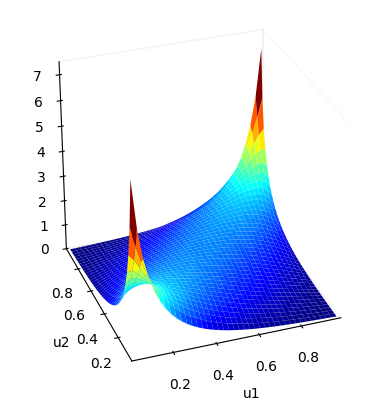

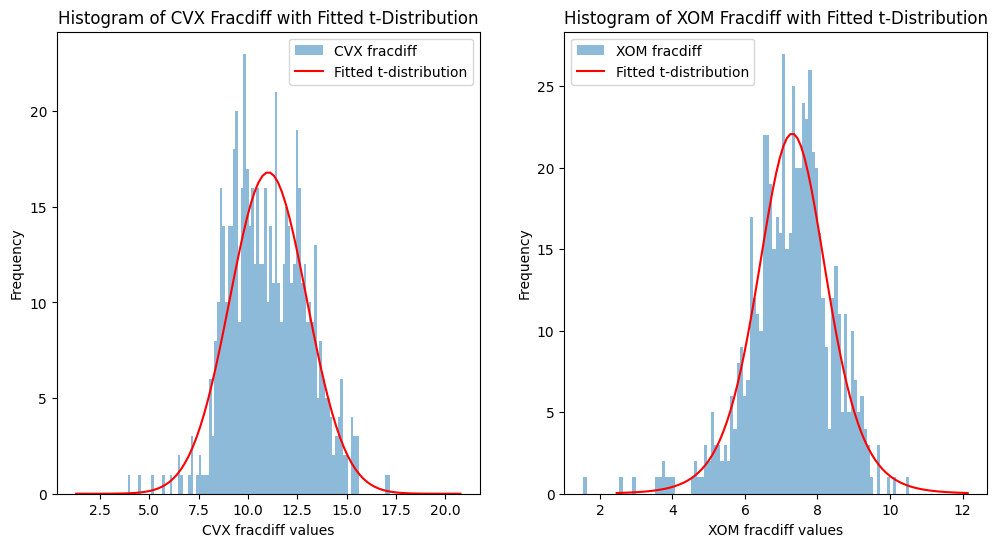

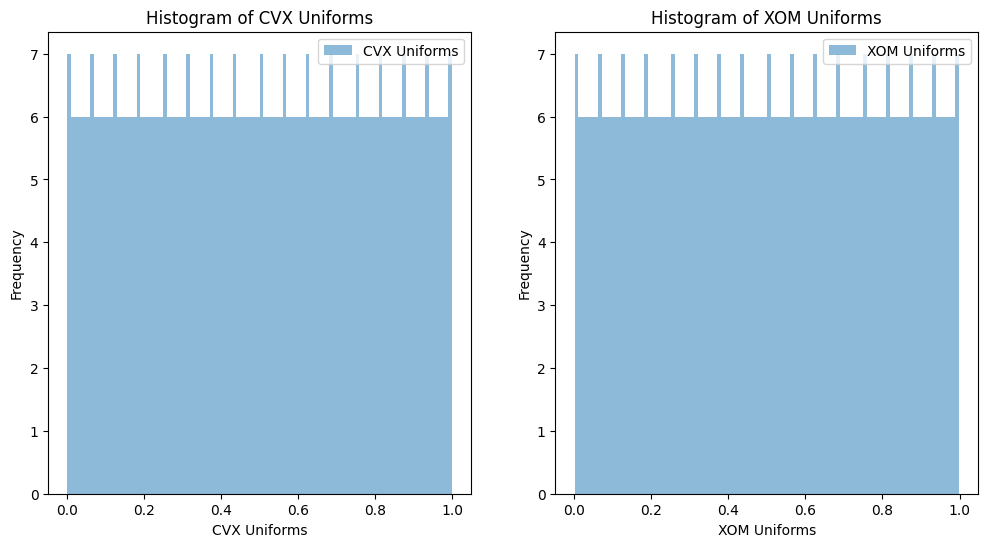

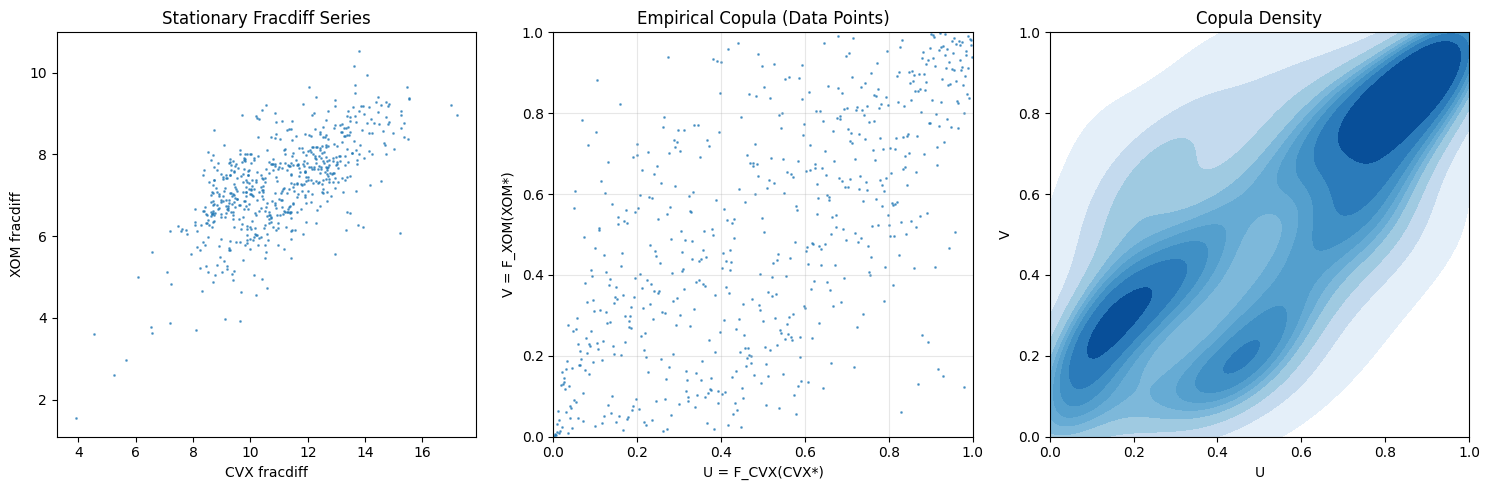

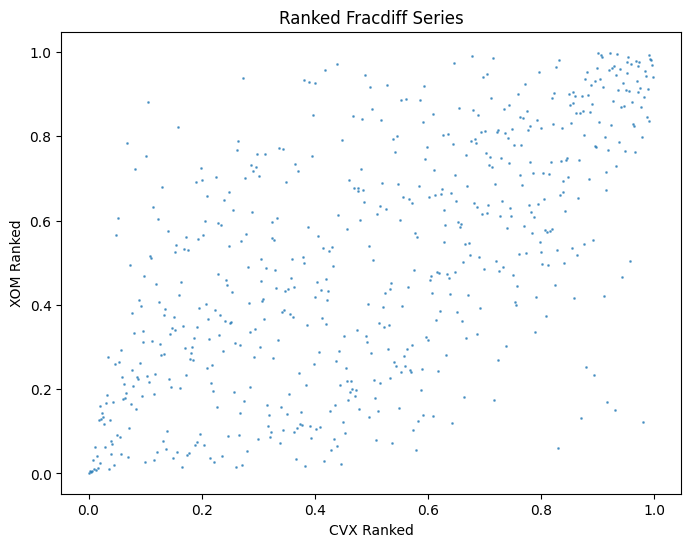

U size: (617,), V size: (617,)


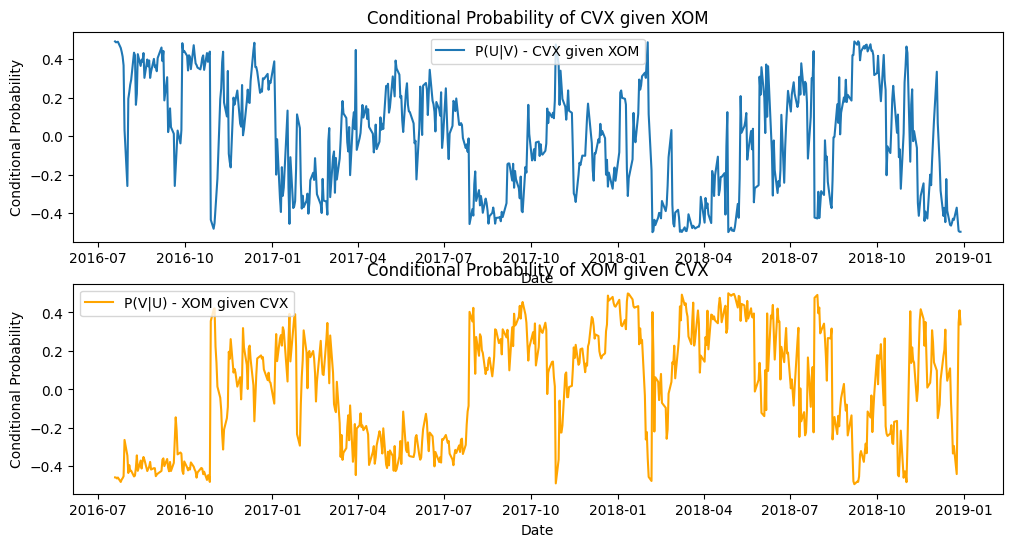

Calculating fractional integration with d=0.3 and threshold=0.0001
Calculating fractional integration with d=0.3 and threshold=0.0001


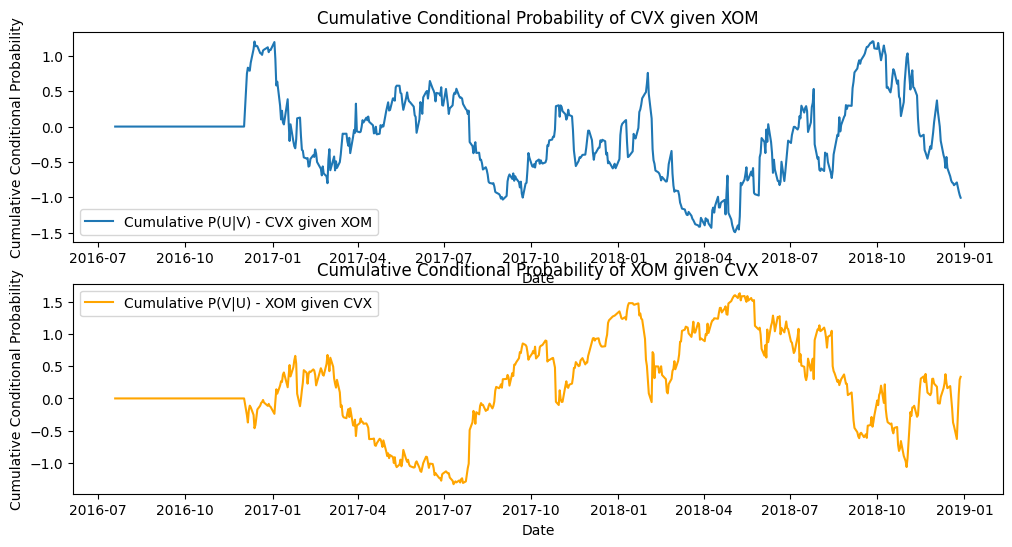

C:\Users\Adam\AppData\Local\Temp\ipykernel_18828\37572268.py:174: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif (Flag_CVX[i-1] == 1 and CMPI_CVX.iloc[i] < exit) or (Flag_CVX[i-1] == -1 and CMPI_CVX.iloc[i] > -exit):
C:\Users\Adam\AppData\Local\Temp\ipykernel_18828\37572268.py:178: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Flag_CVX[i] = Flag_CVX[i-1]
C:\Users\Adam\AppData\Local\Temp\ipykernel_18828\37572268.py:178: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value b

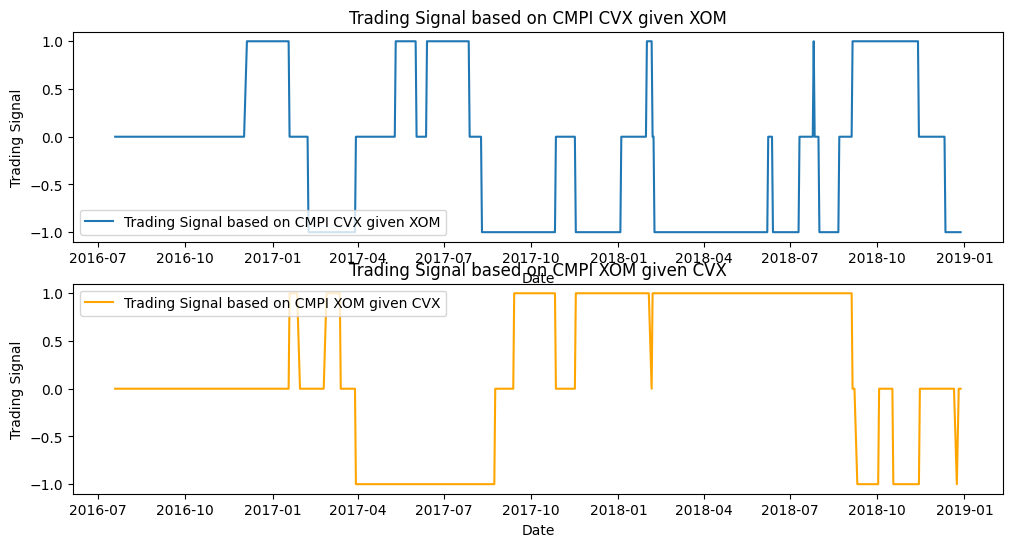

In [ ]:

CVX_fd = fracdiff(CVX, d, threshold=1e-4)
XOM_fd = fracdiff(XOM, d, threshold=1e-4)

from scipy.stats import t
from scipy.stats import jf_skew_t

params_CVX = t.fit(CVX_fd)
params_XOM = t.fit(XOM_fd)
U = t.cdf(CVX_fd, *params_CVX)
V = t.cdf(XOM_fd, *params_XOM)

U_empirical = CVX_fd.rank() / (len(CVX_fd) + 1)
V_empirical = XOM_fd.rank() / (len(XOM_fd) + 1)

# from statsmodels.distributions.copula.api import StudentCopula
import pyvinecopulib as pv


data = pd.DataFrame({
    'CVX': U_empirical,
    'XOM': V_empirical
})

cop = pv.Bicop(family=pv.student)
cop.fit(data.values)

print(cop)
cop.plot()






x = np.linspace(params_CVX[1] - 5*params_CVX[2], params_CVX[1] + 5*params_CVX[2], 100)
plt.figure(figsize=(12, 6))
plt.subplot(1,2, 1)
plt.hist(CVX_fd, bins=100, alpha=0.5, label='CVX fracdiff')
plt.plot(x, t.pdf(x, *params_CVX) * len(CVX_fd) * (np.max(CVX_fd) - np.min(CVX_fd)) / 100, color='red', label='Fitted t-distribution')
plt.xlabel('CVX fracdiff values')
plt.ylabel('Frequency')
plt.title('Histogram of CVX Fracdiff with Fitted t-Distribution')
plt.legend()
x = np.linspace(params_XOM[1] - 5*params_XOM[2], params_XOM[1] + 5*params_XOM[2], 100)
plt.subplot(1,2, 2)
plt.hist(XOM_fd, bins=100, alpha=0.5, label='XOM fracdiff')
plt.plot(x, t.pdf(x, *params_XOM) * len(XOM_fd) * (np.max(XOM_fd) - np.min(XOM_fd)) / 100, color='red', label='Fitted t-distribution')
plt.xlabel('XOM fracdiff values')
plt.ylabel('Frequency')
plt.title('Histogram of XOM Fracdiff with Fitted t-Distribution')
plt.legend()
plt.show()



plt.figure(figsize=(12, 6))
plt.subplot(1,2, 1)
plt.hist(U_empirical, bins=100, alpha=0.5, label='CVX Uniforms')
plt.xlabel('CVX Uniforms')
plt.ylabel('Frequency')
plt.title('Histogram of CVX Uniforms')
plt.legend()
plt.subplot(1,2, 2)
plt.hist(V_empirical, bins=100, alpha=0.5, label='XOM Uniforms')
plt.xlabel('XOM Uniforms')
plt.ylabel('Frequency')
plt.title('Histogram of XOM Uniforms')
plt.legend()
plt.show()



import seaborn as sns
plt.figure(figsize=(15, 5))

# Left: Raw fracdiff series (stationary!)
plt.subplot(1, 3, 1)
plt.scatter(CVX_fd, XOM_fd, alpha=0.6, s=1)
plt.xlabel('CVX fracdiff')
plt.ylabel('XOM fracdiff')
plt.title('Stationary Fracdiff Series')

# Middle: Uniforms (copula space)
plt.subplot(1, 3, 2)
plt.scatter(U_empirical, V_empirical, alpha=0.6, s=1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('U = F_CVX(CVX*)')
plt.ylabel('V = F_XOM(XOM*)')
plt.title('Empirical Copula (Data Points)')
plt.grid(True, alpha=0.3)

# Right: Density heatmap
plt.subplot(1, 3, 3)
sns.kdeplot(x=U_empirical, y=V_empirical, fill=True, cmap='Blues')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('U')
plt.ylabel('V')
plt.title('Copula Density')

plt.tight_layout()
plt.show()

CVX_Ranked = CVX_fd.rank() / (len(CVX_fd) + 1)
XOM_Ranked = XOM_fd.rank() / (len(XOM_fd) + 1)

plt.figure(figsize=(8, 6))
plt.scatter(CVX_Ranked, XOM_Ranked, alpha=0.6, s=1)
plt.xlabel('CVX Ranked')
plt.ylabel('XOM Ranked')
plt.title('Ranked Fracdiff Series')
plt.show()



# Plot Fitted Copula

print(f"U size: {U.shape}, V size: {V.shape}")

UV = np.column_stack((U, V)).astype(np.float64)

CVX_given_XOM = pd.Series(cop.hfunc1(UV), index=CVX_fd.index)
XOM_given_CVX = pd.Series(cop.hfunc2(UV), index=XOM_fd.index)



plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(CVX_given_XOM - .5, label='P(U|V) - CVX given XOM')
plt.xlabel('Date')
plt.ylabel('Conditional Probability')
plt.title('Conditional Probability of CVX given XOM')
plt.legend()

plt.subplot(2,1,2)
plt.plot(XOM_given_CVX - .5, label='P(V|U) - XOM given CVX', color='orange')
plt.xlabel('Date')
plt.ylabel('Conditional Probability')
plt.title('Conditional Probability of XOM given CVX')
plt.legend()
plt.show()


CMPI_CVX = fracint(CVX_given_XOM - .5, d=d)
CMPI_XOM = fracint(XOM_given_CVX - .5, d=d)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(CMPI_CVX, label='Cumulative P(U|V) - CVX given XOM')
plt.xlabel('Date')
plt.ylabel('Cumulative Conditional Probability')
plt.title('Cumulative Conditional Probability of CVX given XOM')
plt.legend()

plt.subplot(2,1,2)
plt.plot(CMPI_XOM, label='Cumulative P(V|U) - XOM given CVX', color='orange')
plt.xlabel('Date')
plt.ylabel('Cumulative Conditional Probability')
plt.title('Cumulative Conditional Probability of XOM given CVX')
plt.legend()
plt.show()

entry = .5
exit = 0.0

# Enter when abs(CMPI) crosses entry level. Exit when it crosses exit level and currently in trade.
Flag_CVX = pd.Series(0, index=CMPI_CVX.index)
in_trade = False
for i in range(1, len(CMPI_CVX)):
    if not in_trade and abs(CMPI_CVX.iloc[i]) > entry:
        Flag_CVX[i] = np.sign(CMPI_CVX.iloc[i])
        in_trade = True
    elif (Flag_CVX[i-1] == 1 and CMPI_CVX.iloc[i] < exit) or (Flag_CVX[i-1] == -1 and CMPI_CVX.iloc[i] > -exit):
        Flag_CVX[i] = 0
        in_trade = False
    else:
        Flag_CVX[i] = Flag_CVX[i-1]

Flag_XOM = pd.Series(0, index=CMPI_XOM.index)
in_trade = False
for i in range(1, len(CMPI_XOM)):
    if not in_trade and abs(CMPI_XOM.iloc[i]) > entry:
        Flag_XOM[i] = np.sign(CMPI_XOM.iloc[i])
        in_trade = True
    elif (Flag_XOM[i-1] == 1 and CMPI_XOM.iloc[i] < exit) or (Flag_XOM[i-1] == -1 and CMPI_XOM.iloc[i] > -exit):
        Flag_XOM[i] = 0
        in_trade = False
    else:
        Flag_XOM[i] = Flag_XOM[i-1]

Flag = pd.Series(0, index=CMPI_CVX.index)
for i in range(1, len(Flag)):
    if Flag.iloc[i-1] == 0 and (Flag_CVX.iloc[i] == 1 and Flag_XOM.iloc[i] == -1): # Enter Long CVX, Short XOM ? 
        Flag[i] = 1
    elif Flag.iloc[i-1] == 0 and (Flag_CVX.iloc[i] == -1 and Flag_XOM.iloc[i] == 1): # Enter Short CVX, Long XOM ?
        Flag[i] = -1
    elif Flag.iloc[i-1] == 1 and (Flag_CVX.iloc[i] == 0 or Flag_XOM.iloc[i] == 0): # Exit Long CVX, Short XOM
        Flag[i] = 0
    elif Flag.iloc[i-1] == -1 and (Flag_CVX.iloc[i] == 0 or Flag_XOM.iloc[i] == 0): # Exit Short CVX, Long XOM
        Flag[i] = 0
    else:
        Flag[i] = Flag.iloc[i-1]


plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(Flag_CVX, label='Trading Signal based on CMPI CVX given XOM')
plt.xlabel('Date')
plt.ylabel('Trading Signal')
plt.title('Trading Signal based on CMPI CVX given XOM')
plt.legend()

plt.subplot(3,1,2)
plt.plot(Flag_XOM, label='Trading Signal based on CMPI XOM given CVX', color='orange')
plt.xlabel('Date')
plt.ylabel('Trading Signal')
plt.title('Trading Signal based on CMPI XOM given CVX')
plt.legend()

plt.subplot(3,1,3)
plt.plot(Flag, label='Combined Trading Signal', color='green')
plt.xlabel('Date')
plt.ylabel('Trading Signal')
plt.title('Combined Trading Signal based on CMPI')
plt.legend()
plt.show()